In [1]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Dataset
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Linear Regression
lr = LinearRegression().fit(X_train, y_train)

# Ridge (L2)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

# Lasso (L1)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)

# Compare R² Scores
print("Linear Regression R²:", r2_score(y_test, lr.predict(X_test)))
print("Ridge Regression R²:", r2_score(y_test, ridge.predict(X_test)))
print("Lasso Regression R²:", r2_score(y_test, lasso.predict(X_test)))


Linear Regression R²: 0.4526027629719197
Ridge Regression R²: 0.41915292635986545
Lasso Regression R²: 0.4718547867276227


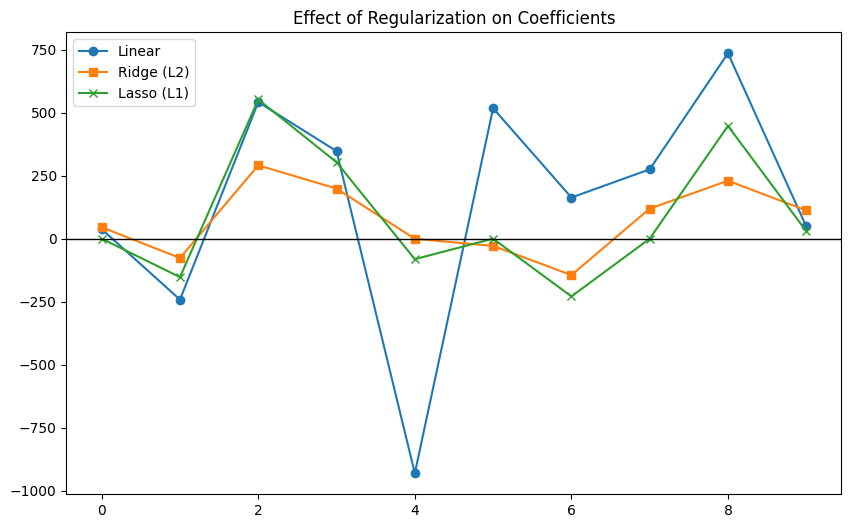

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(lr.coef_, 'o-', label="Linear")
plt.plot(ridge.coef_, 's-', label="Ridge (L2)")
plt.plot(lasso.coef_, 'x-', label="Lasso (L1)")
plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.title("Effect of Regularization on Coefficients")
plt.show()


Linear Regression Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588] ...
SGD Coefficients: [  44.36611581 -181.32755216  480.21031653  310.89566861  -57.73626219] ...

R² Score (Linear Regression): 0.4526027629719197
R² Score (SGD Regressor): 0.4597919589214329

MSE (Linear Regression): 2900.19362849348
MAE (Linear Regression): 42.79409467959994
MSE (SGD Regressor): 2862.1041774031387
MAE (SGD Regressor): 43.05863683782849


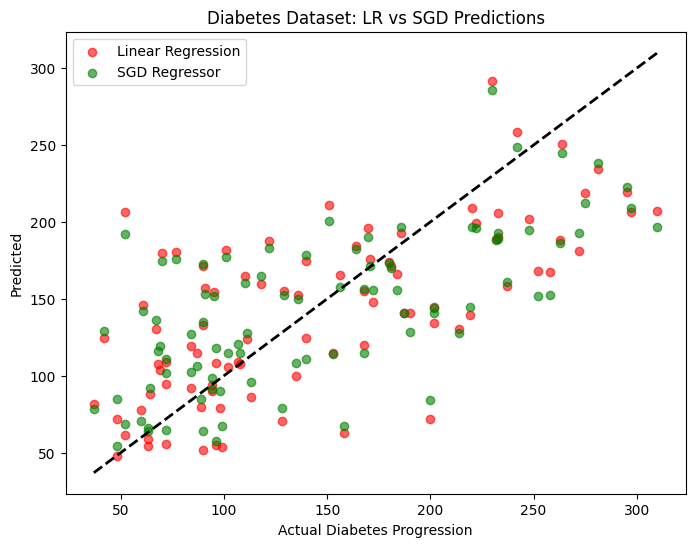

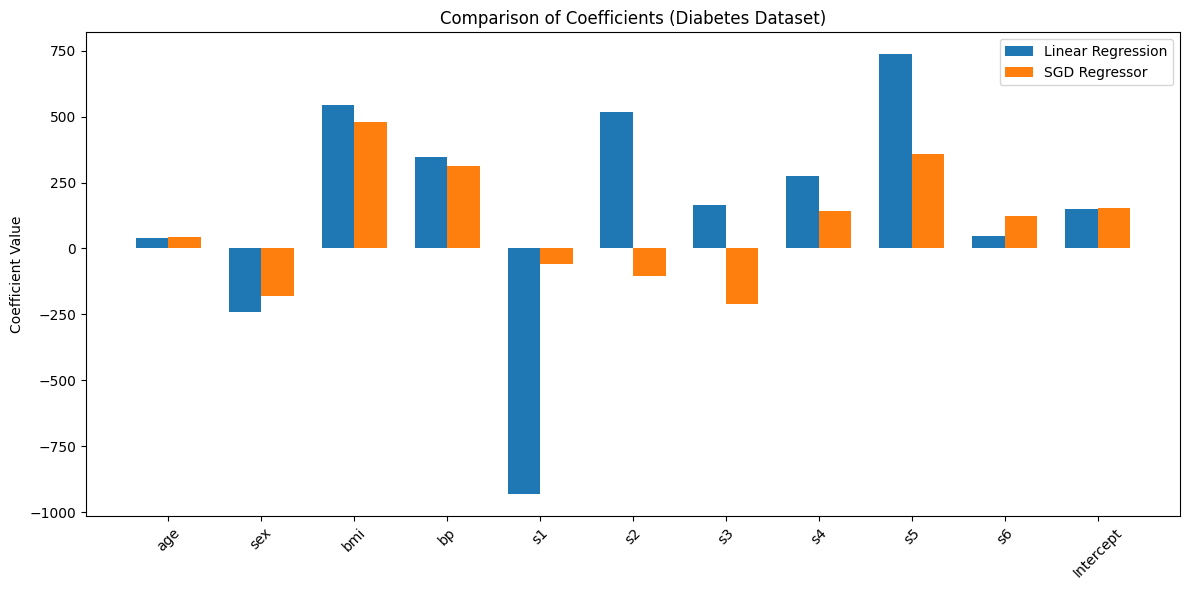

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

# Load dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Linear Regression (Closed Form)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 3. SGD Regressor (Gradient Descent)
sgd = SGDRegressor(max_iter=10000, eta0=0.001, learning_rate="adaptive", random_state=42)
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)

# 4. Results
print("Linear Regression Coefficients:", lr.coef_[:5], "...")  # show first 5
print("SGD Coefficients:", sgd.coef_[:5], "...")
print("\nR² Score (Linear Regression):", r2_score(y_test, y_pred_lr))
print("R² Score (SGD Regressor):", r2_score(y_test, y_pred_sgd))
print("\nMSE (Linear Regression):", mean_squared_error(y_test, y_pred_lr))
print("MAE (Linear Regression):",mean_absolute_error(y_test, y_pred_lr))
print("MSE (SGD Regressor):", mean_squared_error(y_test, y_pred_sgd))
print("MAE (SGD Regressor):",mean_absolute_error(y_test, y_pred_sgd))

# 5. Visualization: Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, color="red", alpha=0.6, label="Linear Regression")
plt.scatter(y_test, y_pred_sgd, color="green", alpha=0.6, label="SGD Regressor")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Diabetes Progression")
plt.ylabel("Predicted")
plt.title("Diabetes Dataset: LR vs SGD Predictions")
plt.legend()
plt.show()

# Get coefficients + intercept
coef_lin = np.append(lr.coef_, lr.intercept_)
coef_sgd = np.append(sgd.coef_, sgd.intercept_)

# Labels for features + intercept
labels = feature_names + ["Intercept"]

# Plot coefficients
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, coef_lin, width, label="Linear Regression")
plt.bar(x + width/2, coef_sgd, width, label="SGD Regressor")

plt.xticks(x, labels, rotation=45)
plt.ylabel("Coefficient Value")
plt.title("Comparison of Coefficients (Diabetes Dataset)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
LR = LinearRegression()
R_Regressor = Ridge()
L_Regressor = Lasso()

LR.fit(X_train,y_train)

Parameters = {"alpha":[1,2,3,4,5,10,12,20,30,40,50]}

ridgeCV = GridSearchCV([R_Regressor],Parameters,scoring= 'r2',cv=5)
ridgeCV.fit(X_train,y_train)
lassoCV = GridSearchCV(L_Regressor,Parameters,scoring= 'r2')
lassoCV.fit(X_train,y_train)

# lr_test_pred = LR.predict(X_test)
# R_test_pred = R_Regressor.predict(X_test)
# La_test_pred = L_Regressor.predict(X_test)
print(ridgeCV.best_estimator_)
print(ridgeCV.best_score_)

print(lassoCV.best_params_)
print(lassoCV.best_score_)


Ridge(alpha=1)
0.38024151335946854
{'alpha': 1}
0.32383659841070683


In [14]:
print(f"R_squared LR: {r2_score(lr_test_pred,y_test)}")
print(f"MSE: {mean_squared_error(lr_test_pred,y_test)}")
print(f"R_squared R: {r2_score(R_test_pred,y_test)}")
print(f"MSE: {mean_squared_error(R_test_pred,y_test)}")
print(f"R_squared L: {r2_score(La_test_pred,y_test)}")
print(f"MSE: {mean_squared_error(La_test_pred,y_test)}")

R_squared LR: 0.006904915832163461
MSE: 2900.19362849348
R_squared R: -1.4096191033767775
MSE: 3077.41593882723
R_squared L: -3.516100361147677
MSE: 3403.5757216070733
